In [7]:
## Critical Imports
import numpy as np
import matplotlib.pyplot as plt

import scipy.constants as const
from matplotlib.ticker import MultipleLocator

# Nested Sampling

#Aesthetics
import matplotlib as mpl
from cmap import Colormap
plt.style.use('style.mplstyle')

# My stuff
from TeraToptica import TeraFlashAnalyzer as TFA, TeraFlashConfig as TFC

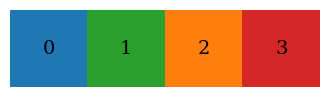

In [8]:
import matplotlib.colors as mcolors

colors = ['C0', 'C2', 'C1', 'C3']
colors = [mcolors.to_rgb(c) for c in colors]

plt.figure(figsize=(4, 1))
plt.imshow([colors], aspect='auto')

for i in range(len(colors)):  # one less because we skipped first color
    plt.annotate(i, (i, 0), color='k', fontsize=14, ha='center', va='center')

plt.gca().set_axis_off()

In [9]:
window = 'boxcar' # Smoothing window type in frequency domain
window_size  = 51 #Determines how many GHz to smooth the spectrum over
mask_bounds = (
              (0, 150), # mask low frequency HD30_batch2
              (545, 570), (740, 770), (1080, 1245), (1390, 1430), # mask waterlines
              (1585, 1810), (1855, 1950),
            #   (2025, 2075), (2100, 2275), (2325, 2500), (2600, 3000),
              (2000, 10000)
              )

tf_cfg = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='separate_files'
)

In [10]:
path = './data/20251124/' #Path to the data directory

open = 'open_2675-2875ps_100avgs'

HD30_0deg   = TFA(path, 'hd30_0deg_2675-2875ps_100avgs',     open, config=tf_cfg)
HD30_15deg  = TFA(path, 'hd30_15deg_2675-2875ps_1000avgs',   open, config=tf_cfg)
HD30_30deg  = TFA(path, 'hd30_30deg_2675-2875ps_1000avgs',   open, config=tf_cfg)
HD30_45deg  = TFA(path, 'hd30_45deg_2_2675-2875ps_1000avgs', open, config=tf_cfg)
HD30_135deg = TFA(path, 'hd30_135deg_2675-2875ps_100avgs',   open, config=tf_cfg)

open_15deg  = TFA(path, 'open_15deg_2675-2875ps_1000avgs', open, config=tf_cfg)
open_30deg  = TFA(path, 'open_30deg_2675-2875ps_1000avgs', open, config=tf_cfg)
open_45deg  = TFA(path, 'open_45deg_3_2675-2875ps_1000avgs', open, config=tf_cfg)

## Frequency-domain data
f_0deg, t_0deg, ut_0deg, mask_0deg, err_0deg, boxnum_0deg = HD30_0deg.get_smoothed_spectra()
f_15deg, t_15deg, ut_15deg, mask_15deg, err_15deg, boxnum_15deg = HD30_15deg.get_smoothed_spectra()
f_30deg, t_30deg, ut_30deg, mask_30deg, err_30deg, boxnum_30deg = HD30_30deg.get_smoothed_spectra()
f_45deg, t_45deg, ut_45deg, mask_45deg, err_45deg, boxnum_45deg = HD30_45deg.get_smoothed_spectra()
f_135deg, t_135deg, ut_135deg, mask_135deg, err_135deg, boxnum_135deg = HD30_135deg.get_smoothed_spectra()

f_open15deg, t_open15deg, ut_open15deg, mask_open15deg, err_open15deg, boxnum_open15deg = open_15deg.get_smoothed_spectra()
f_open30deg, t_open30deg, ut_open30deg, mask_open30deg, err_open30deg, boxnum_open30deg = open_30deg.get_smoothed_spectra()
f_open15deg, t_open15deg, ut_open15deg, mask_open15deg, err_open15deg, boxnum_open15deg = open_15deg.get_smoothed_spectra()

## Time-domain data
T_0deg, pc_0deg = HD30_0deg.get_sample_pulse()
T_15deg, pc_15deg = HD30_15deg.get_sample_pulse()
T_30deg, pc_30deg = HD30_30deg.get_sample_pulse()
T_45deg, pc_45deg = HD30_45deg.get_sample_pulse()
T_135deg, pc_135deg = HD30_135deg.get_sample_pulse()

T_open, pc_open = HD30_0deg.get_base_pulse() # all opens are the same

## ACTIVE DATA DICTIONARY
data = {}

data['0°']      = {'f': f_0deg,   't': t_0deg,   'ut': ut_0deg,   'mask': mask_0deg,   'err': err_0deg,   'boxnum': boxnum_0deg,   'T': T_0deg,   'pc': pc_0deg,   'width': 25.4e-3, 'color': 'k'}
data['15°']     = {'f': f_15deg,  't': t_15deg,  'ut': ut_15deg,  'mask': mask_15deg,  'err': err_15deg,  'boxnum': boxnum_15deg,  'T': T_15deg,  'pc': pc_15deg,  'width': 25.4e-3, 'color': colors[0]}
data['30°']     = {'f': f_30deg,  't': t_30deg,  'ut': ut_30deg,  'mask': mask_30deg,  'err': err_30deg,  'boxnum': boxnum_30deg,  'T': T_30deg,  'pc': pc_30deg,  'width': 25.4e-3, 'color': colors[1]}
data['45°']     = {'f': f_45deg,  't': t_45deg,  'ut': ut_45deg,  'mask': mask_45deg,  'err': err_45deg,  'boxnum': boxnum_45deg,  'T': T_45deg,  'pc': pc_45deg,  'width': 25.4e-3, 'color': colors[2]}
data['135°']    = {'f': f_135deg, 't': t_135deg, 'ut': ut_135deg, 'mask': mask_135deg, 'err': err_135deg, 'boxnum': boxnum_135deg, 'T': T_135deg, 'pc': pc_135deg, 'width': 25.4e-3, 'color': colors[3]}

open_data = {}

open_data['15°']  = {'f': f_open15deg, 't': t_open15deg, 'ut': ut_open15deg, 'mask': mask_open15deg, 'err': err_open15deg, 'boxnum': boxnum_open15deg}
open_data['30°']  = {'f': f_open30deg, 't': t_open30deg, 'ut': ut_open30deg, 'mask': mask_open30deg, 'err': err_open30deg, 'boxnum': boxnum_open30deg}
open_data['45°']  = {'f': f_open15deg, 't': t_open15deg, 'ut': ut_open15deg, 'mask': mask_open15deg, 'err': err_open15deg, 'boxnum': boxnum_open15deg}
open_data['135°'] = {'f': f_open15deg, 't': np.zeros(len(f_open15deg)), 'ut': np.zeros(len(f_open15deg)), 'mask': mask_open15deg, 'err': np.zeros(len(f_open15deg)), 'boxnum': boxnum_open15deg} #safe to ignore

In [11]:
## Initial processing
for sample in data:
    if sample != '0°':
        data[sample]['ut_subtracted'] = data[sample]['ut'] - open_data[sample]['ut']  # Subtract open beam uncertainty from sample uncertainty
        data[sample]['t_subtracted']  = data[sample]['t'] - open_data[sample]['t']

    data[sample]['t'] = np.where((data[sample]['t'] < 0), np.nan, data[sample]['t'])  # Set negative transmission values to zero
    data[sample]['ut'] = np.where((data[sample]['ut'] < 0), np.nan, data[sample]['ut'])  # Set negative transmission values to zero

    data[sample]['f_sampled']  = data[sample]['f'][~data[sample]['mask']][::data[sample]['boxnum']]
    data[sample]['t_sampled']  = data[sample]['t'][~data[sample]['mask']][::data[sample]['boxnum']]
    data[sample]['err_sampled'] = data[sample]['err'][~data[sample]['mask']][::data[sample]['boxnum']]

#find mask stops for plotting purposes
filt0 = next(iter(data)) #generalized it works for any key

mask_starts = np.array((mask_bounds))[:,0]
mask_stops = np.array((mask_bounds))[:,1]

for sample in data:
    data[sample]['width_masked'] = np.tile(data[sample]['width'], (len(data[sample]['f'][~data[sample]['mask']]))) #repeat the width for each data point

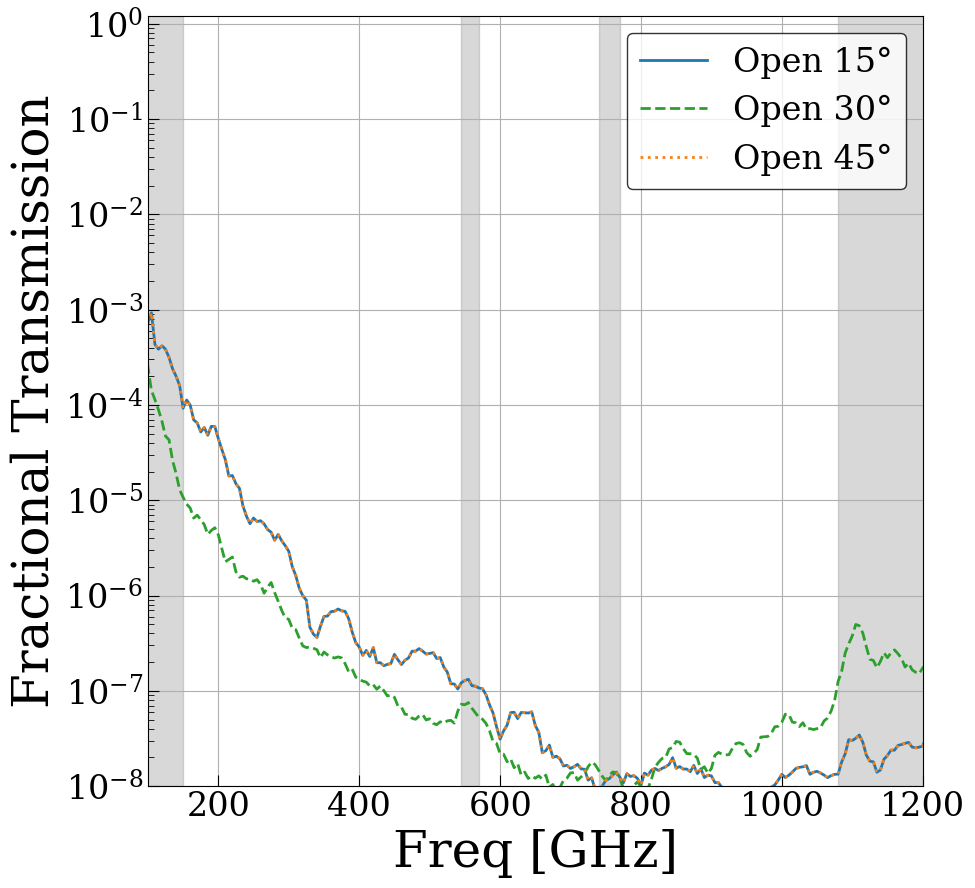

In [12]:
styles = ['-', '-', '--', ':', '-']

fig, ax = plt.subplots(figsize=(10, 10))

# Plot measurements and fits
for i, sample in enumerate(data):
    if sample in ['0°', '135°']:
        continue

    plt.plot(open_data[sample]['f'], open_data[sample]['t'], color=data[sample]['color'], lw=2, ls=styles[i], label=f'Open {sample}')

# plt.plot(f_DSIR, 100*t_DSIR, label='LF 40K DSIR', color='k', lw=3)

for i, j in zip(mask_starts, mask_stops):
    plt.axvspan(i, j, color='gray', alpha=0.3)

# plt.fill_between((0, llim),    1.2, color='gray', alpha=0.5, label='Instrument Limit')
# plt.fill_between((ulim, 2000), 1.2, color='gray', alpha=0.5)

plt.legend(edgecolor='black', fontsize=24, loc='upper right')

plt.xlim(100, 1200)
plt.ylim(1e-8, 1.2e0)
plt.yscale('log')
# ax.yaxis.set_minor_locator(MultipleLocator(5))
plt.grid()
plt.xlabel('Freq [GHz]')
plt.ylabel('Fractional Transmission')
plt.gcf().set_facecolor('white')
plt.show()

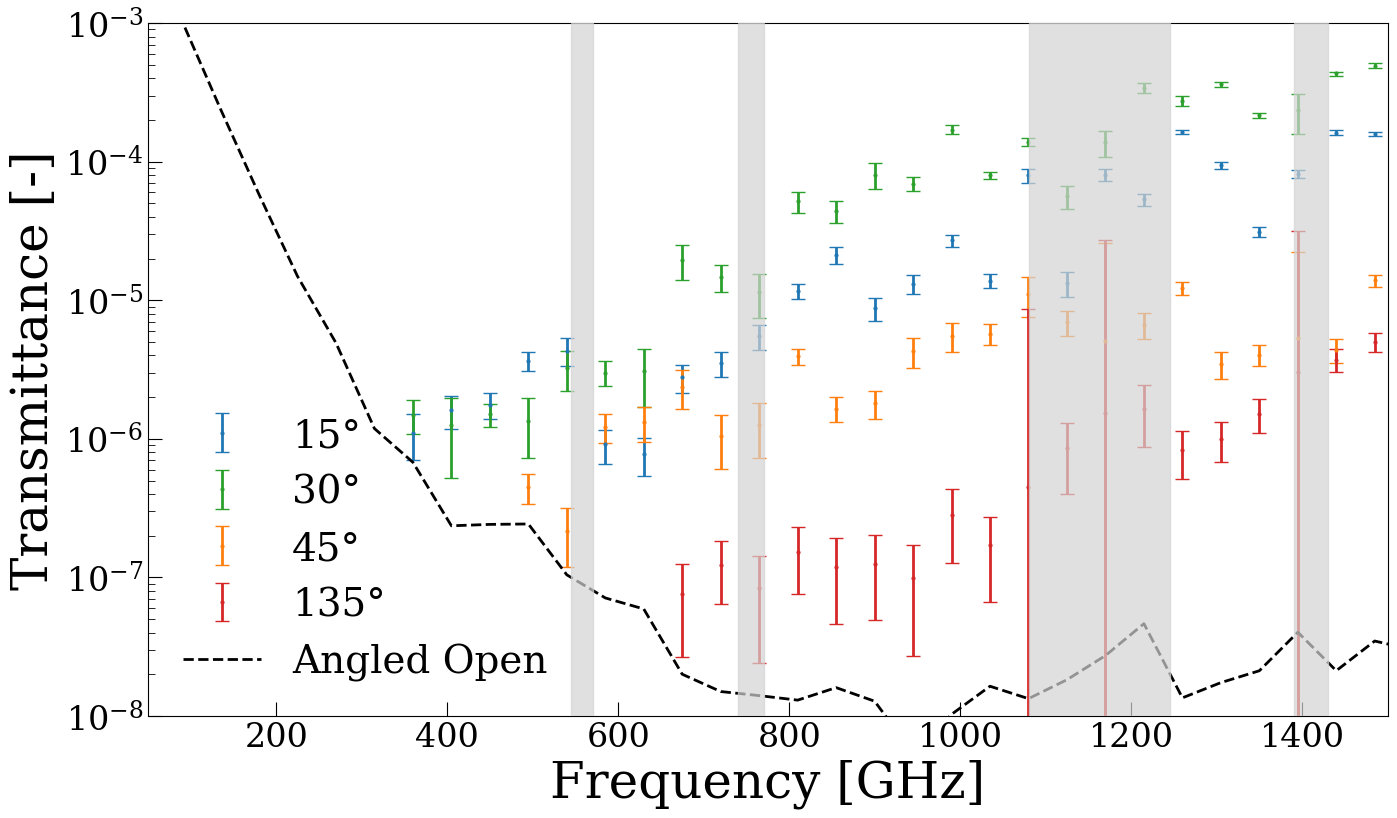

In [13]:
fig, ax = plt.subplots(figsize=(16, 9))

# Plot measurements and fits

f_open = open_data['15°']['f'][::open_data['15°']['boxnum']]
t_open = open_data['15°']['t'][::open_data['15°']['boxnum']]

for sample in data:
    if sample == '0°':
        continue

    f      = data[sample]['f'][::data[sample]['boxnum']]
    t      = data[sample]['t'][::data[sample]['boxnum']]
    t_0deg = data['0°']['t'][::data['0°']['boxnum']]

    open_mask = t >= 1.5*t_open

    plt.errorbar(f[open_mask], t[open_mask]/t_0deg[open_mask],
                    yerr=data[sample]['err'][::data[sample]['boxnum']][open_mask],
                    fmt='o', markersize=2, linewidth=2, capsize=5,
                    label=sample, color=data[sample]['color'])
    
plt.plot(f_open, t_open, color='k', lw=2, ls='--', label=f'Angled Open')

plt.tick_params(axis='both', which='major', length=10)
plt.tick_params(axis='both', which='minor', length=5)

handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 2, 3, 4, 0]
handles = [handles[i] for i in order]
labels  = [labels[i] for i in order]

plt.legend(handles, labels, edgecolor='black', fontsize=28, loc='lower left', frameon=False)

for i, j in zip(mask_starts[1:], mask_stops[1:]):
    plt.axvspan(i, j, color='lightgray', alpha=0.7, zorder=4)

plt.xlim(50, 1500)
plt.ylim(1e-8, 1e-3)
plt.yscale('log')
plt.xlabel('Frequency [GHz]', fontsize=36)
plt.ylabel('Transmittance [-]', fontsize=36)
plt.gcf().set_facecolor('white')
plt.savefig("scattering_mes.pdf", bbox_inches='tight', format='pdf')
plt.show()

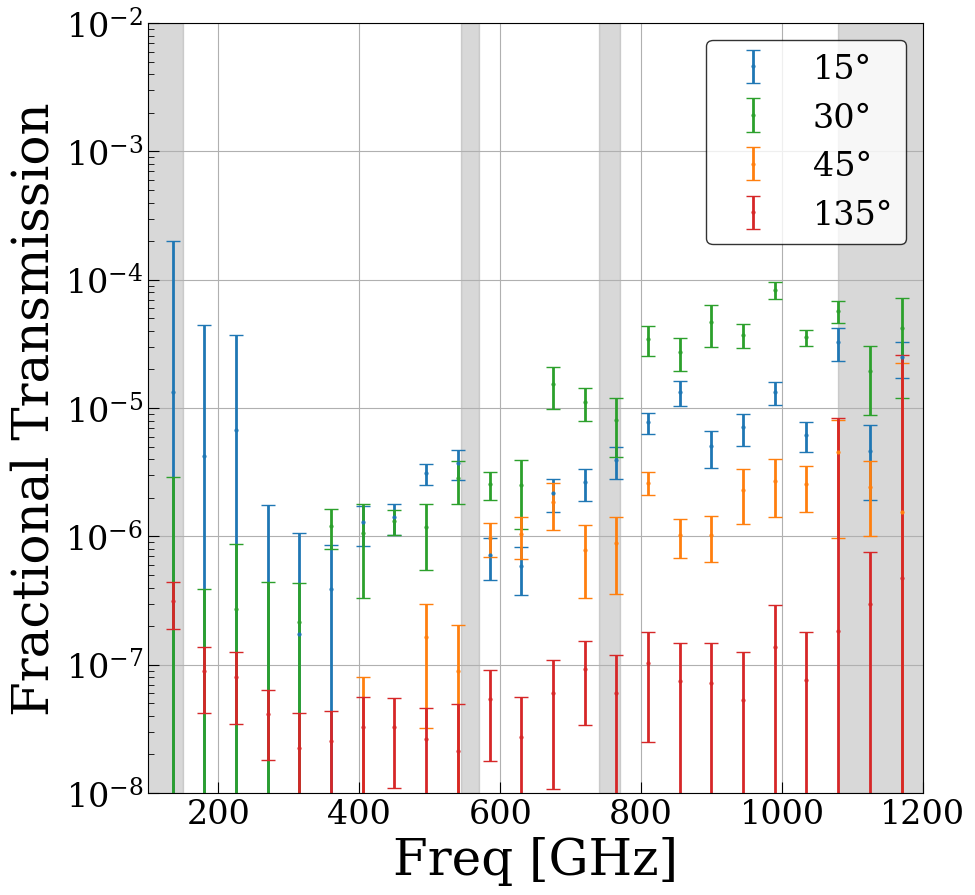

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot measurements and fits
for sample in data:
    if sample == '0°':
        continue
    err = np.sqrt(data[sample]['err'][::data[sample]['boxnum']]**2 + open_data[sample]['err'][::data[sample]['boxnum']]**2)
    plt.errorbar(data[sample]['f'][::data[sample]['boxnum']], data[sample]['t'][::data[sample]['boxnum']]-open_data[sample]['t'][::data[sample]['boxnum']], 
                    yerr=err, fmt='o', markersize=2, linewidth=2, capsize=5,
                    label=sample, color=data[sample]['color'])

for i, j in zip(mask_starts, mask_stops):
    plt.axvspan(i, j, color='gray', alpha=0.3)

plt.legend(edgecolor='black', fontsize=24, loc='upper right')

plt.xlim(100, 1200)
plt.ylim(1e-8, 1e-2)
plt.yscale('log')
# ax.yaxis.set_minor_locator(MultipleLocator(5))
plt.grid()
plt.xlabel('Freq [GHz]')
plt.ylabel('Fractional Transmission')
plt.gcf().set_facecolor('white')
plt.show()

In the non-absorbative limit,
$$ T(\theta \neq 0) = P(\theta)\Omega_{\rm ap} (1 - T(0)) \qquad \Rightarrow \qquad P(\theta) =  \frac{T(\theta \neq 0)}{\Omega_{\rm ap} (1 - T(0))} $$

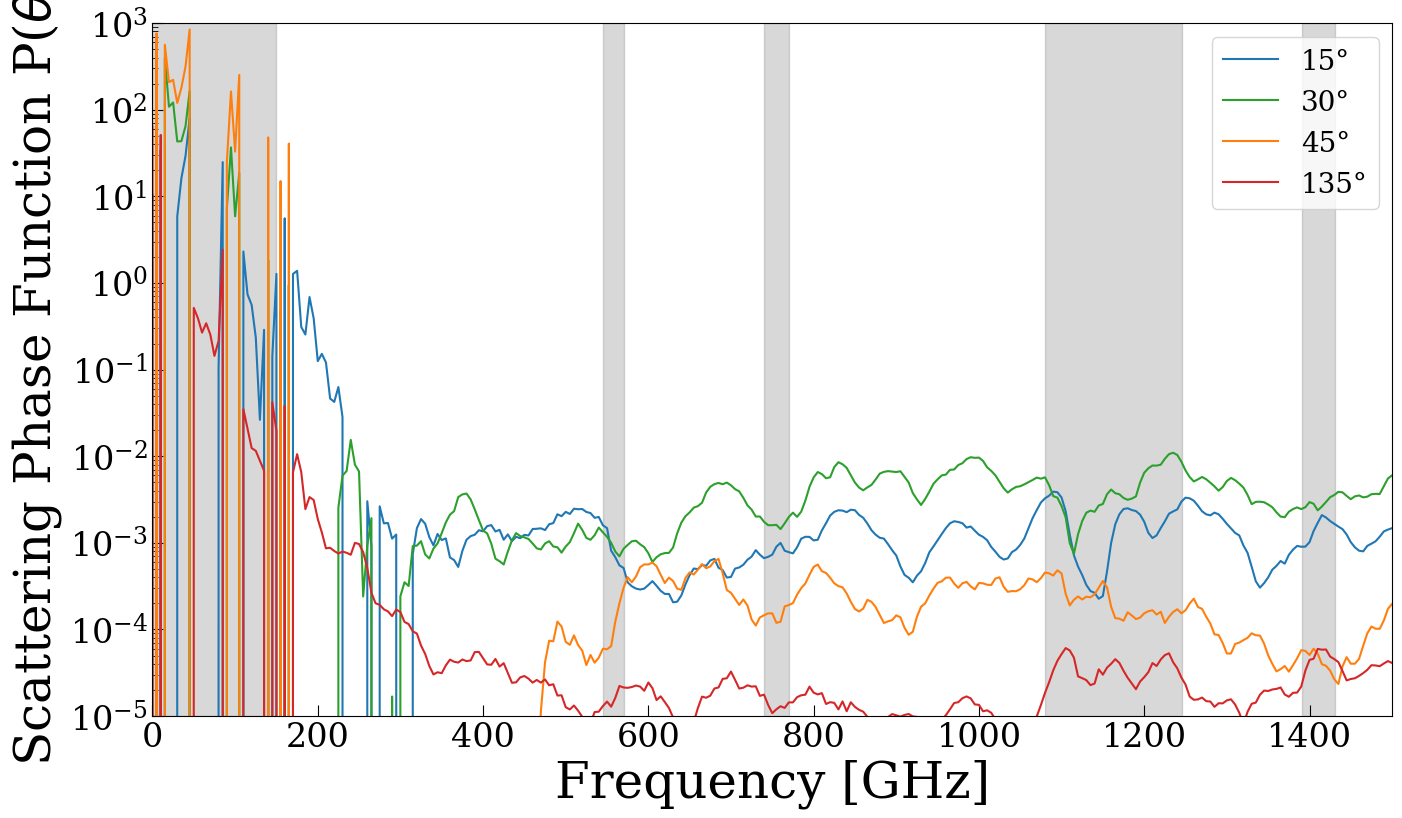

In [15]:
Omega = np.pi*((0.0762/2)/0.52)**2

for sample in data:
    if sample == '0°':
        continue
    angle = int(sample.replace('°',''))
    data[sample]['P'] = data[sample]['t_subtracted']/(Omega * (1 - data['0°']['t']))

    plt.plot(data[sample]['f'], data[sample]['P'], label=sample, color=data[sample]['color'])

for i, j in zip(mask_starts, mask_stops):
    plt.axvspan(i, j, color='gray', alpha=0.3)

plt.xlim(0, 1500)
plt.ylim(1e-5, 1e3)
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Scattering Phase Function P($\\theta$)')
plt.legend(loc='upper right')
plt.show()

In [16]:
import miepython as mie
from miepython import core
import pandas as pd
from astropy import units as u
from astropy.constants import c

def GHz_to_lamb(f):
    return (c / f)

# Frequencies and wavelengths
freq = np.arange(10, 1501, 1)  # GHz
theta = np.linspace(0, 180, 181)
lamb = GHz_to_lamb(freq * u.GHz).to(u.um).value  # wavelength [µm]

# Angles
mus = np.cos(np.deg2rad(theta))

# Particle size (scalar)
d = 3000*u.um    #bubble diameter
n_p = 1.0003      #index of refraction
n_m = 1.54    #index of the matrix
d_um = float(d.to(u.um).value)

n_f = len(freq)
n_ang = len(mus)

# Preallocate arrays: shape (n_freq, n_angles)
Ipar = np.empty((n_f, n_ang))
Iper = np.empty((n_f, n_ang))
I    = np.empty((n_f, n_ang))

# Loop over frequencies; compute all angles at once
for i, lam_um in enumerate(lamb):
    Ipar[i, :], Iper[i, :] = mie.intensities(
        n_p, d_um, lam_um, mus, n_env=n_m
    )

    I[i, :] = 0.5 * (Ipar[i, :] + Iper[i, :])

    norm_par = -2 * np.pi * np.trapezoid(Ipar[i, :], mus)
    norm_per = -2 * np.pi * np.trapezoid(Iper[i, :], mus)
    norm     = -2 * np.pi * np.trapezoid(I[i, :], mus)

    Ipar[i, :] /= norm_par
    Iper[i, :] /= norm_per
    I[i, :]    /= norm

results = []

df = pd.DataFrame({
    "theta_deg": theta,
    "mu": mus,
    "freq_GHz": [freq] * len(theta),
    "lambda_um": [lamb] * len(theta),
    "I": [I[:, j] for j in range(len(theta))],
    "Ipar": [Ipar[:, j] for j in range(len(theta))],
    "Iper": [Iper[:, j] for j in range(len(theta))],
}).set_index("theta_deg")

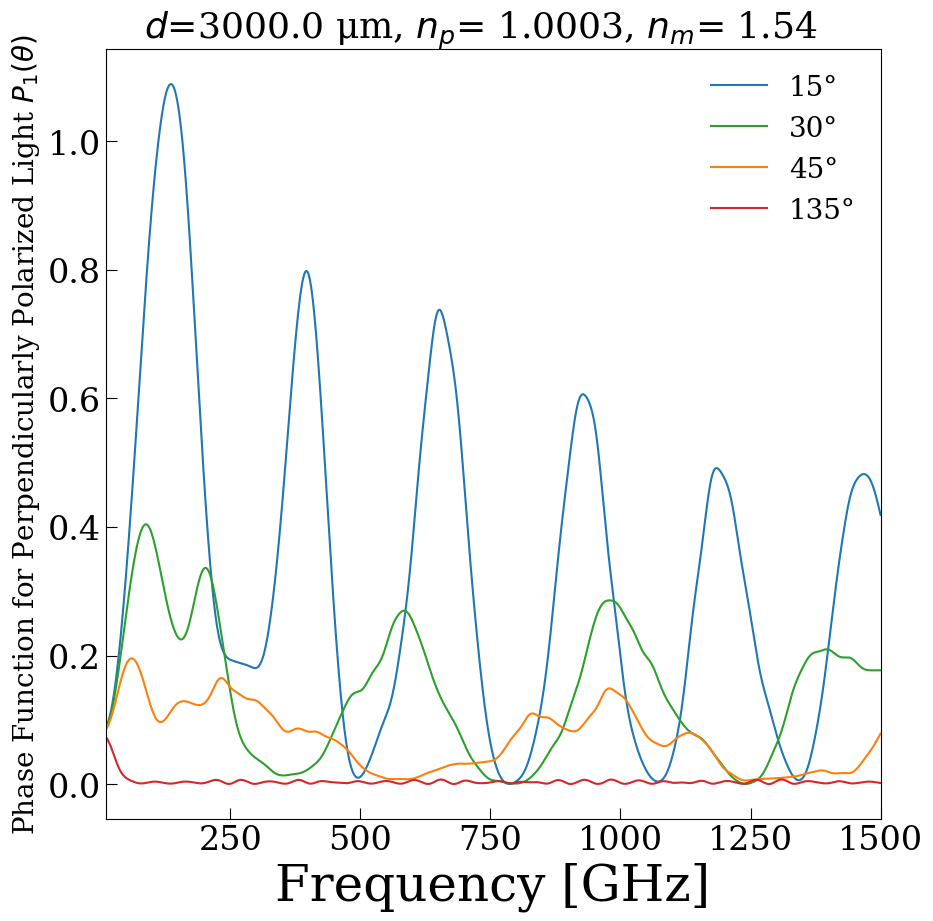

In [17]:
theta_meas = np.array([15, 30, 45, 135])  # degrees

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

for i, theta_ in enumerate(theta_meas):
    row  = df.loc[theta_]       # select the row for this theta
    mu   = row["mu"]
    I    = row["I"]
    Ipar = row["Ipar"]
    Iper = row["Iper"]

    ax.plot(freq, Iper, label=f"{theta_}°", color=colors[i])

# ax.set_ylim(ymin=0)
ax.set_xlim(10, 1500)
ax.legend(loc='upper right', frameon=False)
ax.set_ylabel(r'Phase Function for Perpendicularly Polarized Light $P_1(\theta)$', fontsize=20)
ax.set_xlabel("Frequency [GHz]")
plt.suptitle(r"$d$"f"={d_um} μm, "r"$n_p$"f"= {n_p}, "r"$n_m$"f"= {n_m}", fontsize=26, y=0.92)
plt.gcf().set_facecolor('white')
plt.show()